# Can we extract $\mathcal{H}$ using DNNs as in *Neural Network generated parametrizations of deeply virtual Compton form factors*?

The paper that we are following is: https://arxiv.org/abs/1106.2808

## (1): Initializing Requisite Code/Settings:

### (1.1): Import Libraries:

In [1]:
import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import iminuit
from iminuit import Minuit
from iminuit.cost import LeastSquares
from scipy.integrate import quad, quad_vec
import gepard as g
from gepard.fits import th_KM09a, th_KM09b

In [2]:
print(f"gepard version: {g.__version__}")
print(f"Tensorflow version: {tf.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"imunuit version: {iminuit.__version__}")

gepard version: 0.9.10
Tensorflow version: 2.16.1
pandas version: 2.2.3
Numpy version: 1.26.4
imunuit version: 2.31.1


### (1.2): Matplotlib Plotting Aesthetics:

In [3]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 8.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['xtick.minor.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['ytick.major.size'] = 8.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['ytick.minor.size'] = 2.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.right'] = True

## (2): Data Collection:

### (2.0): Data Collection Definitions:

In [4]:
VERSION_NUMBER = 7
MINOR_NUMBER = 1
MAJOR_MINOR_NUMBER = f"{VERSION_NUMBER}_{MINOR_NUMBER}"

### (2.1): Collect and Load the Train/Test Data used in the Original Paper:

#### (2.1.1): BCA Data:

In [5]:
bca_1_data = pd.read_csv("./data/data_bca_1.csv")
print(bca_1_data.columns)

Index(['bin', 'k', '-t', 'x_b', 'q_squared', 'phi', 'bca_1', 'bca_1_stat_plus',
       'bca_1_stat_minus', 'bca_1_sys_plus', 'bca_1_sys_minus'],
      dtype='object')


#### (2.1.2): BSA Data:

In [6]:
bsa_1_data = pd.read_csv('./data/data_a_lu_i_1.csv')
print(bsa_1_data.columns)

Index(['bin', 'k', '-t', 'x_b', 'q_squared', 'phi', 'a_sin_lu_i_1',
       'a_sin_lu_i_1_stat_plus', 'a_sin_lu_i_1_stat_minus',
       'a_sin_lu_i_1_sys_plus', 'a_sin_lu_i_1_sys_minus'],
      dtype='object')


### (2.2): Can we re-make the plots with the data in the HERMES paper?

The main figure we want to remake is Figure 3 in the original paper (the DNN one). That involves plotting $A_{C}^{\cos{\phi}}$ and $A_{LU}^{\sin{\phi}}$ as they vary individually with $-t$, $x_{B}$, and $Q^{2}$.

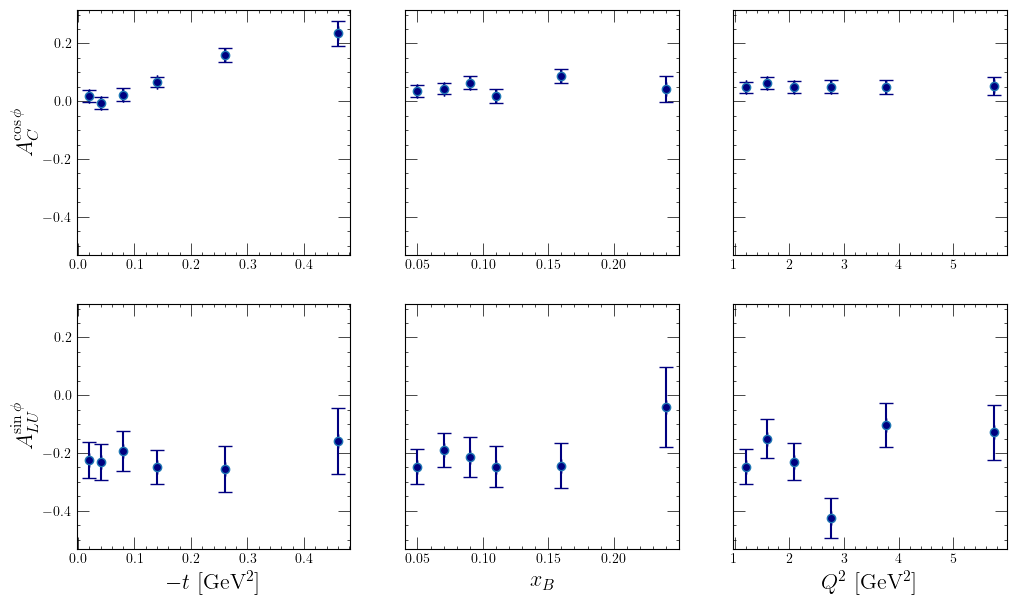

In [7]:
fig, ax = plt.subplots(2, 3, sharey = True, figsize = (12, 7))

ax[0][0].errorbar(
    -1. * bca_1_data["-t"].iloc[:6],
    bca_1_data["bca_1"].iloc[:6],
    xerr = 0.0,
    yerr = bca_1_data["bca_1_stat_plus"].iloc[:6],
    marker = 'o',
    markerfacecolor = '#000080',
    linestyle = "none",
    ecolor = "#000080",
    capsize = 5.)

ax[1][0].errorbar(
    -1.* bsa_1_data["-t"].iloc[:6],
    bsa_1_data["a_sin_lu_i_1"].iloc[:6],
    xerr = 0.0,
    yerr = bsa_1_data["a_sin_lu_i_1_stat_plus"].iloc[:6],
    marker = 'o',
    markerfacecolor = '#000080',
    linestyle = "none",
    ecolor = "#000080",
    capsize = 5.)

ax[0][1].errorbar(
    bca_1_data["x_b"].iloc[6:6+6],
    bca_1_data["bca_1"].iloc[6:6+6],
    xerr = 0.0,
    yerr = bca_1_data["bca_1_stat_plus"].iloc[6:6+6],
    marker = 'o',
    markerfacecolor = '#000080',
    linestyle = "none",
    ecolor = "#000080",
    capsize = 5.)

ax[1][1].errorbar(
    bsa_1_data["x_b"].iloc[6:6+6],
    bsa_1_data["a_sin_lu_i_1"].iloc[6:6+6],
    xerr = 0.0,
    yerr = bsa_1_data["a_sin_lu_i_1_stat_plus"].iloc[6:6+6],
    marker = 'o',
    markerfacecolor = '#000080',
    linestyle = "none",
    ecolor = "#000080",
    capsize = 5.)

ax[0][2].errorbar(
    bca_1_data["q_squared"].iloc[6+6:],
    bca_1_data["bca_1"].iloc[6+6:],
    xerr = 0.0,
    yerr = bca_1_data["bca_1_stat_plus"].iloc[6+6:],
    marker = 'o',
    markerfacecolor = '#000080',
    linestyle = "none",
    ecolor = "#000080",
    capsize = 5.,)

ax[1][2].errorbar(
    bsa_1_data["q_squared"].iloc[6+6:],
    bsa_1_data["a_sin_lu_i_1"].iloc[6+6:],
    xerr = 0.0,
    yerr = bsa_1_data["a_sin_lu_i_1_stat_plus"].iloc[6+6:],
    marker = 'o',
    markerfacecolor = '#000080',
    linestyle = "none",
    ecolor = "#000080",
    capsize = 5.)

# How to make the subplots' y-axis invisible:
# ax[1].get_yaxis().set_visible(False)
# ax[2].get_yaxis().set_visible(False)

ax[1][0].set_xlabel(r"$-t$ [GeV$^{2}$]", fontsize = 16)
ax[1][1].set_xlabel(r'$x_{B}$', fontsize = 16)
ax[1][2].set_xlabel(r'$Q^{2}$ [GeV$^{2}$]', fontsize = 16)

ax[0][0].set_ylabel(r"$A_{C}^{\cos \phi}$", fontsize = 16)
ax[1][0].set_ylabel(r"$A_{LU}^{\sin \phi}$", fontsize = 16)

fig.savefig(f"./version_{VERSION_NUMBER}/plots/observable_data_v{MAJOR_MINOR_NUMBER}.png")
fig.savefig(f"./version_{VERSION_NUMBER}/plots/observable_data_v{MAJOR_MINOR_NUMBER}.eps")

plt.show()

The plots above are correct. These roughly correspond to the ones used in the original paper. The axes on the upper row of subplots are not scaled nicely, but they do feature all of the correct data.

## (3): Data Preprocessing:

### (3.1): How large is the raw dataset?

In [8]:
# Specifically, this will return the number of ROWS in the Pandas DF:
print(f"Total datapoints in raw BCA dataset: {len(bca_1_data)}")
print(f"Total datapoints in raw BSA dataset: {len(bsa_1_data)}")

Total datapoints in raw BCA dataset: 18
Total datapoints in raw BSA dataset: 18


Take a look at the BCA data:

In [9]:
bca_1_data.head()

,bin,k,-t,x_b,q_squared,phi,bca_1,bca_1_stat_plus,bca_1_stat_minus,bca_1_sys_plus,bca_1_sys_minus
0,1,NaN,-0.02,0.07,1.71,NaN,0.018,0.020,0.020,0.004,0.004
1,2,NaN,-0.04,0.09,2.22,NaN,-0.007,0.020,0.020,0.004,0.004
2,3,NaN,-0.08,0.10,2.44,NaN,0.022,0.022,0.022,0.011,0.011
3,4,NaN,-0.14,0.11,2.72,NaN,0.067,0.018,0.018,0.012,0.012
4,5,NaN,-0.26,0.12,3.13,NaN,0.160,0.025,0.025,0.019,0.019


Take a look at the BSA data:

In [10]:
bsa_1_data.head()

,bin,k,-t,x_b,q_squared,phi,a_sin_lu_i_1,a_sin_lu_i_1_stat_plus,a_sin_lu_i_1_stat_minus,a_sin_lu_i_1_sys_plus,a_sin_lu_i_1_sys_minus
0,1,NaN,-0.02,0.07,1.71,NaN,-0.225,0.062,0.062,0.010,0.010
1,2,NaN,-0.04,0.09,2.22,NaN,-0.231,0.063,0.063,0.016,0.016
2,3,NaN,-0.08,0.10,2.44,NaN,-0.193,0.069,0.069,0.009,0.009
3,4,NaN,-0.14,0.11,2.72,NaN,-0.249,0.059,0.059,0.013,0.013
4,5,NaN,-0.26,0.12,3.13,NaN,-0.256,0.080,0.080,0.013,0.013


### (3.2): Make A DF with *All* Observables:

In [11]:
all_raw_data = pd.concat(
    [bca_1_data, bsa_1_data], 
    axis = 0, # combine along the rows
    ignore_index = True)

### (3.3): Define What Becomes the $x$ and $y$ Data:

**Important**: Define here what you want to train on!

In [12]:
x = bsa_1_data[["-t", "x_b"]]
y = bsa_1_data["a_sin_lu_i_1"]
yerr = bsa_1_data["a_sin_lu_i_1_stat_plus"]

### (3.4): Train-Test Split Here:

In [13]:
x_training, x_validation, y_training, y_validation = train_test_split(
    x,
    y,
    test_size = (11 - 5), # https://arxiv.org/pdf/1106.2808, pg. 9
    shuffle = True)

### (3.5): How large is the training dataset?

In [14]:
# The number of ROWS in the Pandas DF:
print(f"Total datapoints in raw dataset: {len(x_training)}")

Total datapoints in raw dataset: 12


### (3.6): What does the training dataset look like?

In [15]:
x_training[["-t", "x_b"]].head()

,-t,x_b
14,-0.11,0.08
4,-0.26,0.12
13,-0.10,0.07
17,-0.22,0.20
16,-0.15,0.13


In [16]:
y_training.head()

14   -0.230
4    -0.256
13   -0.151
17   -0.129
16   -0.103
Name: a_sin_lu_i_1, dtype: float64

### (3.7): How large is the validation dataset?

In [17]:
# The number of ROWS in the Pandas DF:
print(f"Total datapoints in raw dataset: {len(x_validation)}")

Total datapoints in raw dataset: 6


### (3.8): What does the validation dataset look like?

In [18]:
x_validation.head()

,-t,x_b
5,-0.46,0.12
11,-0.23,0.24
2,-0.08,0.10
10,-0.16,0.16
3,-0.14,0.11


In [19]:
y_validation.head()

5    -0.158
11   -0.040
2    -0.193
10   -0.244
3    -0.249
Name: a_sin_lu_i_1, dtype: float64

### (3.9): How large is the testing dataset?

There is no testing dataset this time around. We don't have nearly enough datapoints to partition the data further.

## (4): Model Definitions:

### (4.1): Static Quantities Used in Loss Computation:

**Important**: `Q_SQUARED` ($Q^{2}$) and `_LAB_K_BEAM` ($k$) are treated as fixed the ENTIRE TIME during training.

#### (4.1.1): Statics in Loss Computation:

In [20]:
_MASS_OF_PROTON_IN_GEV = .93827208816
_ELECTRIC_FORM_FACTOR_CONSTANT = 0.710649
_PROTON_MAGNETIC_MOMENT = 2.79284734463

#### (4.1.2): Important Statics (Kinematics)

`_Q_SQUARED` and `_LAB_K_BEAM` are **here**!!

In [21]:
_LAB_K_BEAM = 27.6
_Q_SQUARED = 2.0

### (4.2): Relevant Functions in Loss Computation:

The DNN paper does a poor job presenting how it evaluated its loss; these equations below come from the HERMES paper that the DNN one took their data from. I am assuming the DNN paper also used the equations in the HERMES paper to compute the BSA and BCA.

In [22]:
def compute_fe(t):
    return tf.divide(1., tf.square(1. - tf.divide(t, _ELECTRIC_FORM_FACTOR_CONSTANT)))

def compute_fg(fe):
    return _PROTON_MAGNETIC_MOMENT * fe

def compute_f2(t, fe, fg):
    tau = tf.divide(-1. * t, 4. * tf.square(_MASS_OF_PROTON_IN_GEV))
    numerator = fg - fe
    denominator = 1. + tau
    return tf.divide(numerator, denominator)

def compute_f1(fg, f2):
    return fg - f2

def compute_epsilon(xb, q_squared):
    return tf.divide(2. * xb * _MASS_OF_PROTON_IN_GEV, tf.sqrt(q_squared))

def compute_y(k_beam, q_squared, epsilon):
    return tf.divide(tf.sqrt(q_squared), epsilon * k_beam)

def compute_m_1_1(t, xb, f1, f2, cff_h, cff_h_tilde, cff_e):
    # equation 1.7 in the HERMES paper:
    return (f1 * cff_h + tf.divide(xb, 2. - xb) * (f1 + f2) * cff_h_tilde - tf.divide(t, 4. * _MASS_OF_PROTON_IN_GEV**2) * f2 * cff_e)

def compute_c_int_1_(t, q_squared, y, cff_contribution):
    beam_helicity = 1.
    k = tf.sqrt(-t) / q_squared
    return 8. * k * beam_helicity * (2. - 2. * y + y * y) * cff_contribution

def compute_s_int_1_(t, q_squared, y, cff_contribution):
    beam_helicity = 1.
    k = tf.sqrt(-t) / q_squared
    return 8. * k * beam_helicity * y * (2. - y) * cff_contribution

### (4.3): Testing Functions in Loss Computation:

So annoying... You have to pass in a `tf.constant` if you want to evaluate these functions instead of just a `float` or something because all the functions use the `tf.math` functions. (Never mind? See the second code cell below.)

In [23]:
test_t = -0.17
test_xb = 0.34
test_q_squared = 1.82
test_k = 5.75
test_fe = compute_fe(test_t)
test_fg = compute_fg(test_fe)
test_f2 = compute_f2(test_t, test_fe, test_fg)
test_f1 = compute_f1(test_fg, test_f2)

print(test_fe)
print(test_fg)
print(test_f2)
print(test_f1)

tf.Tensor(0.6511853, shape=(), dtype=float32)
tf.Tensor(1.8186611, shape=(), dtype=float32)
tf.Tensor(1.1137103, shape=(), dtype=float32)
tf.Tensor(0.7049508, shape=(), dtype=float32)


In [24]:
test_epsilon = compute_epsilon(test_xb, test_q_squared)
test_y = compute_y(test_k, test_q_squared, test_epsilon)

print(test_epsilon)
print(test_y)

tf.Tensor(0.47293562, shape=(), dtype=float32)
tf.Tensor(0.4960961, shape=(), dtype=float32)


I used the [`BKM10_Spin_Polarized` Mathematica notebook functions](https://github.com/Woofmagic/BKM10_Spin_Polarized/blob/main/mathematica/bkm10_test.nb) to do the cross-check above.

In [25]:
test_m_1_1 = compute_m_1_1(test_t, test_xb, test_f1, test_f2, (-0.897, 2.421), 0., 0.)

print(test_m_1_1)
print(test_f1 * (-0.897, 2.421) == test_m_1_1) # because the other CFFs are 0 here

tf.Tensor([-0.6323409  1.7066859], shape=(2,), dtype=float32)
tf.Tensor([ True  True], shape=(2,), dtype=bool)


In [26]:
test_c_1 = compute_c_int_1_(test_t, test_q_squared, test_y, (-0.897, 2.421))
test_s_1 = compute_s_int_1_(test_t, test_q_squared, test_y, (-0.897, 2.421))

print(test_c_1)
print(8. * np.sqrt(-1. * test_t) * (2. - 2. * test_y + test_y**2) * -0.897 / test_q_squared)
print(8. * np.sqrt(-1. * test_t) * (2. - 2. * test_y + test_y**2) * -0.897 / test_q_squared == test_c_1[0])

print(test_s_1)
print(8. * np.sqrt(-1. * test_t) * 1. * test_y * (2. - test_y) * 2.421 / test_q_squared)
print(8. * np.sqrt(-1. * test_t) * 1. * test_y * (2. - test_y) * 2.421 / test_q_squared == test_c_1[1])

tf.Tensor([-2.0384731  5.5018325], shape=(2,), dtype=float32)
tf.Tensor(-2.0384734, shape=(), dtype=float32)
tf.Tensor(False, shape=(), dtype=bool)
tf.Tensor([-1.21289   3.273586], shape=(2,), dtype=float32)
tf.Tensor(3.2735858, shape=(), dtype=float32)
tf.Tensor(False, shape=(), dtype=bool)


It's pretty close, though.

### (4.4): Mean-Squared Error Loss Function:

We only use this for checking if the custom loss business is working.

In [27]:
class MeanSquaredError(tf.keras.losses.Loss):
    def __init__(self, name = "mean_squared_error"):
        super().__init__(name = name)

    def call(self, true_values, predicted_values):
        residuals = true_values - predicted_values
        squared_residuals = tf.square(residuals)
        mean_squared_error = tf.reduce_mean(squared_residuals)
        return mean_squared_error

### (4.5): Custom Loss Function:

Here, we define a custom loss. The main thing here is that it needs to be able to transform the model output into a different number to be able to check with the true values.

In [28]:
class CustomizedLoss(tf.keras.losses.Loss):
    def __init__(self, name = "custom_loss"):
        super().__init__(name = name)

    def call(self, true_values, predicted_values):
        
        # extract the output of the two neurons:
        cff_h_real = predicted_values[:, 0]
        cff_h_imag = predicted_values[:, 1]
        t = predicted_values[:, 2]
        xb = predicted_values[:, 3]

        fe = compute_fe(t)
        fg = compute_fg(fe)
        f2 = compute_f2(t, fe, fg)
        f1 = compute_f1(fg, f2)
        
        epsilon = compute_epsilon(xb, _Q_SQUARED)
        y_kin = compute_y(_LAB_K_BEAM, _Q_SQUARED, epsilon)
        m_real_1_1 = compute_m_1_1(t, xb, f1, f2, cff_h_real, 0., 0.)
        m_imag_1_1 = compute_m_1_1(t, xb, f1, f2, cff_h_imag, 0., 0.)

        # turn this on if the data is BCA:
        c_int_1 = compute_c_int_1_(t, _Q_SQUARED, y_kin, m_real_1_1)

        # turn this on if the data is BSA (specifically BSA sin(1*phi)):
        s_int_1 = compute_s_int_1_(t, _Q_SQUARED, y_kin, m_imag_1_1)
        
        residuals = true_values - s_int_1
        squared_residuals = tf.square(residuals)
        mean_squared_error = tf.reduce_mean(squared_residuals)
        return mean_squared_error   

### (4.5): Model Architecture:

In [29]:
def cff_h_model():
    kinematic_inputs = tf.keras.Input(shape = (2,))
    hidden = tf.keras.layers.Dense(13, activation = "tanh")(kinematic_inputs)
    hidden = tf.keras.layers.Dense(13, activation = "tanh")(hidden)
    hidden = tf.keras.layers.Dense(13, activation = "tanh")(hidden)
    # hidden = tf.keras.layers.Dense(13, activation = "relu")(hidden)

    # linear activation is default activation if `activation` key is not specified: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense
    cff_outputs = tf.keras.layers.Dense(2, activation = "linear", name = "cff_h")(hidden)
    
    full_model_outputs = tf.keras.layers.Concatenate(name = "kinematics_and_cffs")([cff_outputs, kinematic_inputs])
    model = tf.keras.Model(inputs = kinematic_inputs, outputs = full_model_outputs)
    model.compile(optimizer = tf.keras.optimizers.Adam(), loss = CustomizedLoss())
    return model

## (5): Fitting the Model:

### (5.1): Get a TF Summary of the DNN Model:

In [30]:
cff_h_model().summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 13)        │         39 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 13)        │        182 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 13)        │        182 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cff_h (Dense)       │ (None, 2)         │         28 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ kinematics_and_cffs │ (None, 4)         │          0 │ cff_h[0][0],      │
│ (Concatenate)       │                   │            │ input_layer[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 431 (1.68 KB)

 Trainable params: 431 (1.68 KB)

 Non-trainable params: 0 (0.00 B)

### (5.2): **Begin the Replica Method**

In [31]:
number_of_replicas = 50 # https://arxiv.org/pdf/1106.2808, pg. 9

for replica in range(number_of_replicas):

    dnn_model = cff_h_model()

    dnn_model_history = dnn_model.fit(
        x_training,
        y_training,
        validation_data = (x_validation, y_validation), # https://arxiv.org/pdf/1106.2808, pg. 9
        epochs = 200, # https://arxiv.org/pdf/1106.2808, pg. 9
        # callbacks = [
        #     # to stop overfitting
        #     tf.keras.callbacks.EarlyStopping(monitor = "val_loss")
        # ]
        verbose = 0
        )

    dnn_model.save(f"./version_{VERSION_NUMBER}/replicas/replica_{replica + 1}_v{MAJOR_MINOR_NUMBER}.keras")

    loss_curves = dnn_model_history.history["loss"]
    validation_curves = dnn_model_history.history["val_loss"]
    
    # loss, accuracy = dnn_model.evaluate(x_validation, y_validation, verbose = 1)
    # print(f"Test Loss for Replica {replica + 1}: {loss}")
    # print(f"Test Accuracy for Replica {replica + 1}: {accuracy}")

    curves_fig, curves_ax = plt.subplots(1, figsize = (6, 6))
    curves_ax.set_title(f"Learning Curves for Replica ${replica + 1}$")
    curves_ax.set_xlabel("Epoch Number", fontsize = 16)
    curves_ax.set_ylabel("Loss", fontsize = 16)
    curves_ax.plot(loss_curves, color = "black", label = "Training Curve")
    curves_ax.plot(validation_curves, color = "red", label = "Validation Curve")
    curves_ax.legend()
    curves_fig.savefig(f"./version_{VERSION_NUMBER}/learning_curves/lc_replica_{replica + 1}_v{MAJOR_MINOR_NUMBER}.png")
    curves_fig.savefig(f"./version_{VERSION_NUMBER}/learning_curves/lc_replica_{replica + 1}_v{MAJOR_MINOR_NUMBER}.eps")
    plt.close()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript back

## (6): DNN Predictions:

### (6.1): Prepare Smooth Input Data:

In [32]:
range_of_t = np.linspace(x_training["-t"].min(), x_training["-t"].max())
range_of_t

array([-0.26      , -0.25510204, -0.25020408, -0.24530612, -0.24040816,
       -0.2355102 , -0.23061224, -0.22571429, -0.22081633, -0.21591837,
       -0.21102041, -0.20612245, -0.20122449, -0.19632653, -0.19142857,
       -0.18653061, -0.18163265, -0.17673469, -0.17183673, -0.16693878,
       -0.16204082, -0.15714286, -0.1522449 , -0.14734694, -0.14244898,
       -0.13755102, -0.13265306, -0.1277551 , -0.12285714, -0.11795918,
       -0.11306122, -0.10816327, -0.10326531, -0.09836735, -0.09346939,
       -0.08857143, -0.08367347, -0.07877551, -0.07387755, -0.06897959,
       -0.06408163, -0.05918367, -0.05428571, -0.04938776, -0.0444898 ,
       -0.03959184, -0.03469388, -0.02979592, -0.02489796, -0.02      ])

In [33]:
range_of_x_b = np.linspace(x_training["x_b"].min(), x_training["x_b"].max())
range_of_x_b

array([0.05      , 0.05306122, 0.05612245, 0.05918367, 0.0622449 ,
       0.06530612, 0.06836735, 0.07142857, 0.0744898 , 0.07755102,
       0.08061224, 0.08367347, 0.08673469, 0.08979592, 0.09285714,
       0.09591837, 0.09897959, 0.10204082, 0.10510204, 0.10816327,
       0.11122449, 0.11428571, 0.11734694, 0.12040816, 0.12346939,
       0.12653061, 0.12959184, 0.13265306, 0.13571429, 0.13877551,
       0.14183673, 0.14489796, 0.14795918, 0.15102041, 0.15408163,
       0.15714286, 0.16020408, 0.16326531, 0.16632653, 0.16938776,
       0.17244898, 0.1755102 , 0.17857143, 0.18163265, 0.18469388,
       0.1877551 , 0.19081633, 0.19387755, 0.19693878, 0.2       ])

### (6.3): Load all Replicas

In [34]:
replica_paths = sorted(glob.glob(f"./version_{VERSION_NUMBER}/replicas/replica_*_v{MAJOR_MINOR_NUMBER}.keras"))
replicas = [tf.keras.models.load_model(path, compile = False) for path in replica_paths]
print(f"Loaded {len(replicas)} replica models.")

Loaded 50 replica models.


### (6.4): Predict with Replicas using *Entire Dataset*

In [35]:
# this is the entire dataset! (i.e. training+validation)
x_data = bsa_1_data[["x_b", "-t"]].values.astype(np.float32)

all_predictions = []

for replica in replicas:
    predicted_outputs = replica.predict(x_data) # predicting using x_data
    all_predictions.append(predicted_outputs)

all_predictions = np.array(all_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━

`all_predictions` is a NumPy array of arrays; index corresponds to replica number; each array is $\mathcal{H}$ as a function of $x_{B}$ and $t$. Seems like it just added to the array... `[outputs, inputs]`.

In [36]:
all_predictions

array([[[ 0.03021428, -0.21314314,  0.07      , -0.02      ],
        [ 0.01730986, -0.18402748,  0.09      , -0.04      ],
        [ 0.00088347, -0.11011402,  0.1       , -0.08      ],
        ...,
        [-0.01569008, -0.0115653 ,  0.1       , -0.13      ],
        [-0.03164055,  0.01179995,  0.13      , -0.15      ],
        [-0.07598454,  0.11017357,  0.2       , -0.22      ]],

       [[-0.0190894 , -0.21242915,  0.07      , -0.02      ],
        [-0.03251134, -0.1832639 ,  0.09      , -0.04      ],
        [-0.06749094, -0.10875633,  0.1       , -0.08      ],
        ...,
        [-0.11425757, -0.00890663,  0.1       , -0.13      ],
        [-0.12442447,  0.01449603,  0.13      , -0.15      ],
        [-0.16854388,  0.11412648,  0.2       , -0.22      ]],

       [[-0.01141258, -0.20988892,  0.07      , -0.02      ],
        [-0.02545892, -0.17675406,  0.09      , -0.04      ],
        [-0.04217371, -0.08788995,  0.1       , -0.08      ],
        ...,
        [-0.05818661,  0.03

In [37]:
all_predictions.shape

(50, 18, 4)

### (6.5): Compute BSA/BCA Across Replicas with $\mathcal{H}$ Prediction

In [38]:
discrete_bsa_predictions = []

for index, _ in enumerate(all_predictions):
    xb = all_predictions[index][:, 2]
    t = all_predictions[index][:, 3]
    cff_h_real = all_predictions[index][:, 0]
    cff_h_imag = all_predictions[index][:, 1]

    fe = compute_fe(t)
    fg = compute_fg(fe)
    f2 = compute_f2(t, fe, fg)
    f1 = compute_f1(fg, f2)
    epsilon = compute_epsilon(xb, _Q_SQUARED)
    y_kin = compute_y(_LAB_K_BEAM, _Q_SQUARED, epsilon)
    m_real_1_1 = compute_m_1_1(t, xb, f1, f2, cff_h_real, 0., 0.)
    m_imag_1_1 = compute_m_1_1(t, xb, f1, f2, cff_h_imag, 0., 0.)
    c_int_1 = compute_c_int_1_(t, _Q_SQUARED, y_kin, m_real_1_1)
    s_int_1 = compute_s_int_1_(t, _Q_SQUARED, y_kin, m_imag_1_1)

    discrete_bsa_predictions.append(s_int_1)

discrete_bsa_predictions = np.array(discrete_bsa_predictions)

In [39]:
discrete_bsa_predictions.shape

(50, 18)

Take a mean across all of the $50$ replicas means using `np.mean()` along the "zeroth" axis.

In [40]:
mean_bsa = np.mean(discrete_bsa_predictions, axis = 0)
std_dev_bsa = np.std(discrete_bsa_predictions, axis = 0)

bsa_mean = np.mean(discrete_bsa_predictions, axis = 0)
bsa_min = np.min(discrete_bsa_predictions, axis = 0)
bsa_max = np.max(discrete_bsa_predictions, axis = 0)
bsa_q1 = np.percentile(discrete_bsa_predictions, 25, axis = 0)
bsa_q3 = np.percentile(discrete_bsa_predictions, 75, axis = 0)

bsa_percentile_10 = np.percentile(discrete_bsa_predictions, 10, axis = 0)
bsa_percentile_20 = np.percentile(discrete_bsa_predictions, 20, axis = 0)
bsa_percentile_30 = np.percentile(discrete_bsa_predictions, 30, axis = 0)
bsa_percentile_40 = np.percentile(discrete_bsa_predictions, 40, axis = 0)
bsa_median = np.percentile(discrete_bsa_predictions, 50, axis = 0)
bsa_percentile_60 = np.percentile(discrete_bsa_predictions, 60, axis = 0)
bsa_percentile_70 = np.percentile(discrete_bsa_predictions, 70, axis = 0)
bsa_percentile_80 = np.percentile(discrete_bsa_predictions, 80, axis = 0)
bsa_percentile_90 = np.percentile(discrete_bsa_predictions, 90, axis = 0)

Let's check if the mean is indeed of length $18$.

In [41]:
mean_bsa

array([-0.09207154, -0.09175051, -0.07103214, -0.01239562,  0.11961947,
        0.3160295 , -0.06254141, -0.07123189, -0.04478579, -0.03356981,
       -0.00239492,  0.02922444, -0.08986214, -0.05929924, -0.04555378,
       -0.0222163 , -0.00571821,  0.03419729], dtype=float32)

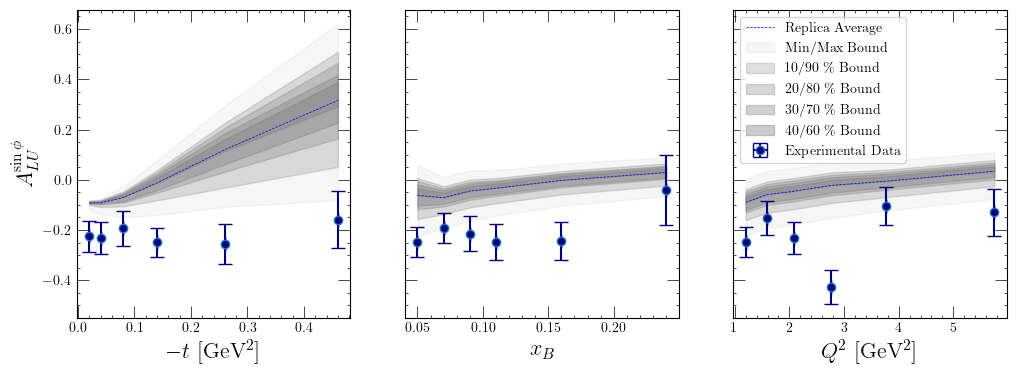

In [42]:
fig2, ax2 = plt.subplots(1, 3, sharey = True, figsize = (12, 4))

ax2[0].errorbar(
    -1. * bsa_1_data["-t"].iloc[:6],
    bsa_1_data["a_sin_lu_i_1"].iloc[:6],
    xerr = 0.0,
    yerr = bsa_1_data["a_sin_lu_i_1_stat_plus"].iloc[:6],
    marker = 'o',
    markerfacecolor = '#000080',
    linestyle = "none",
    ecolor = "#000080",
    capsize = 5.,
    label = "Experimental Data")

ax2[1].errorbar(
    bsa_1_data["x_b"].iloc[6:6+6],
    bsa_1_data["a_sin_lu_i_1"].iloc[6:6+6],
    xerr = 0.0,
    yerr = bsa_1_data["a_sin_lu_i_1_stat_plus"].iloc[6:6+6],
    marker = 'o',
    markerfacecolor = '#000080',
    linestyle = "none",
    ecolor = "#000080",
    capsize = 5.,
    label = "Experimental Data")

ax2[2].errorbar(
    bsa_1_data["q_squared"].iloc[6+6:],
    bsa_1_data["a_sin_lu_i_1"].iloc[6+6:],
    xerr = 0.0,
    yerr = bsa_1_data["a_sin_lu_i_1_stat_plus"].iloc[6+6:],
    marker = 'o',
    markerfacecolor = '#000080',
    linestyle = "none",
    ecolor = "#000080",
    capsize = 5.,
    label = "Experimental Data")

ax2[0].plot(
    -1. * bsa_1_data["-t"].iloc[:6],
    bsa_mean[:6],
    label = r'Replica Average',
    color = "blue",
    linewidth = 0.5,
    linestyle = 'dashed')

ax2[0].fill_between(
    x = -1. * bsa_1_data["-t"].iloc[:6],
    y1 = bsa_max[:6],
    y2 = bsa_min[:6],
    label = r'Min/Max Bound',
    color = "lightgray",
    alpha = 0.2)

ax2[0].fill_between(
    x = -1. * bsa_1_data["-t"].iloc[:6],
    y1 = bsa_percentile_90[:6],
    y2 = bsa_percentile_10[:6],
    label = r'10/90 \% Bound',
    color = "gray",
    alpha = 0.25)

ax2[0].fill_between(
    x = -1. * bsa_1_data["-t"].iloc[:6],
    y1 = bsa_percentile_80[:6],
    y2 = bsa_percentile_20[:6],
    label = r'20/80 \% Bound',
    color = "gray",
    alpha = 0.3)

ax2[0].fill_between(
    x = -1. * bsa_1_data["-t"].iloc[:6],
    y1 = bsa_percentile_70[:6],
    y2 = bsa_percentile_30[:6],
    label = r'30/70 \% Bound',
    color = "gray",
    alpha = 0.35)

ax2[0].fill_between(
    x = -1. * bsa_1_data["-t"].iloc[:6],
    y1 = bsa_percentile_60[:6],
    y2 = bsa_percentile_40[:6],
    label = r'40/60 \% Bound',
    color = "gray",
    alpha = 0.4)

ax2[1].plot(
    bsa_1_data["x_b"].iloc[6:6+6],
    bsa_mean[6:6+6],
    label = r'Replica Average',
    color = "blue",
    linewidth = 0.5,
    linestyle = 'dashed')

ax2[1].fill_between(
    x = bsa_1_data["x_b"].iloc[6:6+6],
    y1 = bsa_max[6:6+6],
    y2 = bsa_min[6:6+6],
    label = r'Min/Max Bound',
    color = "lightgray",
    alpha = 0.2)

ax2[1].fill_between(
    x = bsa_1_data["x_b"].iloc[6:6+6],
    y1 = bsa_percentile_90[6:6+6],
    y2 = bsa_percentile_10[6:6+6],
    label = r'10/90 \% Bound',
    color = "gray",
    alpha = 0.25)

ax2[1].fill_between(
    x = bsa_1_data["x_b"].iloc[6:6+6],
    y1 = bsa_percentile_80[6:6+6],
    y2 = bsa_percentile_20[6:6+6],
    label = r'20/80 \% Bound',
    color = "gray",
    alpha = 0.3)

ax2[1].fill_between(
    x = bsa_1_data["x_b"].iloc[6:6+6],
    y1 = bsa_percentile_70[6:6+6],
    y2 = bsa_percentile_30[6:6+6],
    label = r'30/70 \% Bound',
    color = "gray",
    alpha = 0.35)

ax2[1].fill_between(
    x = bsa_1_data["x_b"].iloc[6:6+6],
    y1 = bsa_percentile_60[6:6+6],
    y2 = bsa_percentile_40[6:6+6],
    label = r'40/60 \% Bound',
    color = "gray",
    alpha = 0.4)

ax2[2].plot(
    bsa_1_data["q_squared"].iloc[6+6:],
    bsa_mean[6+6:],
    label = r'Replica Average',
    color = "blue",
    linewidth = 0.5,
    linestyle = 'dashed')

ax2[2].fill_between(
    x = bsa_1_data["q_squared"].iloc[6+6:],
    y1 = bsa_max[6+6:],
    y2 = bsa_min[6+6:],
    label = r'Min/Max Bound',
    color = "lightgray",
    alpha = 0.2)

ax2[2].fill_between(
    x = bsa_1_data["q_squared"].iloc[6+6:],
    y1 = bsa_percentile_90[6+6:],
    y2 = bsa_percentile_10[6+6:],
    label = r'10/90 \% Bound',
    color = "gray",
    alpha = 0.25)

ax2[2].fill_between(
    x = bsa_1_data["q_squared"].iloc[6+6:],
    y1 = bsa_percentile_80[6+6:],
    y2 = bsa_percentile_20[6+6:],
    label = r'20/80 \% Bound',
    color = "gray",
    alpha = 0.3)

ax2[2].fill_between(
    x = bsa_1_data["q_squared"].iloc[6+6:],
    y1 = bsa_percentile_70[6+6:],
    y2 = bsa_percentile_30[6+6:],
    label = r'30/70 \% Bound',
    color = "gray",
    alpha = 0.35)

ax2[2].fill_between(
    x = bsa_1_data["q_squared"].iloc[6+6:],
    y1 = bsa_percentile_60[6+6:],
    y2 = bsa_percentile_40[6+6:],
    label = r'40/60 \% Bound',
    color = "gray",
    alpha = 0.4)

# ax2[1].plot(
#     bsa_1_data["x_b"].iloc[6:6+6],
#     mean_bsa[6:6+6],
#     color = "red",
#     linewidth = 0.5,
#     linestyle = 'dashed')

# ax2[1].fill_between(
#     x = bsa_1_data["x_b"].iloc[6:6+6],
#     y1 = (mean_bsa + std_dev_bsa)[6:6+6],
#     y2 = (mean_bsa - std_dev_bsa)[6:6+6],
#     alpha = 0.2,
#     color = "red",
#     hatch = "/")

# ax2[2].plot(
#     bsa_1_data["q_squared"].iloc[6+6:],
#     mean_bsa[6+6:],
#     color = "red",
#     linewidth = 0.5,
#     linestyle = 'dashed')

# ax2[2].fill_between(
#     x = bsa_1_data["q_squared"].iloc[6+6:],
#     y1 = (mean_bsa + std_dev_bsa)[6+6:],
#     y2 = (mean_bsa - std_dev_bsa)[6+6:],
#     alpha = 0.2,
#     color = "red",
#     hatch = "/")

ax2[0].set_xlabel(r"$-t$ [GeV$^{2}$]", fontsize = 16)
ax2[1].set_xlabel(r'$x_{B}$', fontsize = 16)
ax2[2].set_xlabel(r'$Q^{2}$ [GeV$^{2}$]', fontsize = 16)
ax2[0].set_ylabel(r'$A_{LU}^{\sin{\phi}}$', fontsize = 16)

plt.legend()

fig2.savefig(f"./version_{VERSION_NUMBER}/plots/dnn_gpd_h_vs_bsa_1_v{MAJOR_MINOR_NUMBER}.png")

plt.show()
plt.close()

### (6.6): Compute Mean $Re[\mathcal{H}]$ and $Im[\mathcal{H}]$ using Replicas:

#### (6.6.1): Need the KM15 Model Functions:

In [43]:
nval = 1.35
pval = 1.
nsea = 1.5
rsea = 1.
psea = 2.
bsea = 4.6
Mval = 0.789
rval = 0.918
bval = 0.4
C0 = 2.768
Msub = 1.204
Mtval = 3.993
rtval = 0.881
btval = 0.4
ntval = 0.6
Msea = np.sqrt(0.482)
rpi = 2.646
Mpi = 4.

def compute_km15_cffs(QQ, xB, t, k = 0.0):
    """
    ## Description:
    Evaluate the KM15 model for CFFs at the given kinematics.
    """

    # (X): Calculate the skewnesss, xi:
    xi = xB / (2.0 - xB)
    
    alpha_val = 0.43 + 0.85 * t
    alpha_sea = 1.13 + 0.15 * t
    Ct = C0 / (1.0 - t / Msub**2)**2

    def fHval(x):
        return (nval * rval / (1 + x) *
                ((2 * x) / (1 + x))**(-alpha_val) *
                ((1 - x) / (1 + x))**bval /
                (1 - ((1 - x) / (1 + x)) * (t / Mval**2))**pval)

    def fHsea(x):
        return (nsea * rsea / (1 + x) *
                ((2 * x) / (1 + x))**(-alpha_sea) *
                ((1 - x) / (1 + x))**bsea /
                (1 - ((1 - x) / (1 + x)) * (t / Msea**2))**psea)

    def fHtval(x):
        return (ntval * rtval / (1 + x) *
                ((2 * x) / (1 + x))**(-alpha_val) *
                ((1 - x) / (1 + x))**btval /
                (1 - ((1 - x) / (1 + x)) * (t / Mtval**2)))

    def fImH(x):
        return np.pi * ((8. / 9.) * fHval(x) + (1. / 9.) * fHsea(x))

    def fImHt(x):
        return np.pi * (8. / 9.) * fHtval(x)

    def fPV_ReH(x):
        return -2. * x / (x + xi) * fImH(x)

    def fPV_ReHt(x):
        return -2. * xi / (x + xi) * fImHt(x)

    DR_ReH, _ = quad(fPV_ReH, 1e-6, 1.0, weight = 'cauchy', wvar = xi)
    DR_ReHt, _ = quad(fPV_ReHt, 1e-6, 1.0, weight = 'cauchy', wvar = xi)

    # (X): Re[H]:
    real_h_km15 = DR_ReH / np.pi - Ct
    
    # (X): Im[H]:
    imag_h_km15 = fImH(xi)

    return real_h_km15, imag_h_km15

#### (6.6.2): For Plotting, Need to Fix on Values of $t$:

In the paper, in Figure 5, they fix on $t = -0.2 \text{GeV}^{2} $ and $t = -0.02 \text{GeV}^{2}$.

In [44]:
# just to be curious:
average_t_value = bsa_1_data["-t"].mean()
print(f"dataset average t: {average_t_value}")

# the paper's values:
fixed_t_value_1 = -0.2
fixed_t_value_2 = -0.02

dataset average t: -0.14444444444444446


### (6.7): Evaluate KM15 Predictions Across Continuous $x_{B}$ Range at Two Fixed Values of $-t$:

In [45]:
km15_predictions_value_1 = [compute_km15_cffs(_Q_SQUARED, xb, fixed_t_value_1) for xb in range_of_x_b]
km15_predictions_value_2 = [compute_km15_cffs(_Q_SQUARED, xb, fixed_t_value_2) for xb in range_of_x_b]

#### (6.7.1): Extract the KM15 Values for the Re[$\mathcal{H}$] and Im[$\mathcal{H}$] from Above:

In [46]:
km15_re_h_predictions_value_1 = [km15_h[0] for km15_h in km15_predictions_value_1]
km15_im_h_predictions_value_1 = [km15_h[1] for km15_h in km15_predictions_value_1]
km15_re_h_predictions_value_2 = [km15_h[0] for km15_h in km15_predictions_value_2]
km15_im_h_predictions_value_2 = [km15_h[1] for km15_h in km15_predictions_value_2]

#### (6.7.2): Need to Get a Continuous Grid of Data for DNN Interpolation:

In [47]:
pd.DataFrame(data = {'t': range_of_t, 'x_b': range_of_x_b}).values

array([[-0.26      ,  0.05      ],
       [-0.25510204,  0.05306122],
       [-0.25020408,  0.05612245],
       [-0.24530612,  0.05918367],
       [-0.24040816,  0.0622449 ],
       [-0.2355102 ,  0.06530612],
       [-0.23061224,  0.06836735],
       [-0.22571429,  0.07142857],
       [-0.22081633,  0.0744898 ],
       [-0.21591837,  0.07755102],
       [-0.21102041,  0.08061224],
       [-0.20612245,  0.08367347],
       [-0.20122449,  0.08673469],
       [-0.19632653,  0.08979592],
       [-0.19142857,  0.09285714],
       [-0.18653061,  0.09591837],
       [-0.18163265,  0.09897959],
       [-0.17673469,  0.10204082],
       [-0.17183673,  0.10510204],
       [-0.16693878,  0.10816327],
       [-0.16204082,  0.11122449],
       [-0.15714286,  0.11428571],
       [-0.1522449 ,  0.11734694],
       [-0.14734694,  0.12040816],
       [-0.14244898,  0.12346939],
       [-0.13755102,  0.12653061],
       [-0.13265306,  0.12959184],
       [-0.1277551 ,  0.13265306],
       [-0.12285714,

### (6.8): Evaluate Replicas at Continuous Kinematic Grid

In [48]:
all_predictions_value_1 = []
all_predictions_value_2 = []

for replica in replicas:
    predicted_outputs_value_1 = replica.predict(pd.DataFrame(data = {'t': fixed_t_value_1, 'x_b': range_of_x_b}).values.astype(np.float32))
    all_predictions_value_1.append(predicted_outputs_value_1)
    
    predicted_outputs_value_2 = replica.predict(pd.DataFrame(data = {'t': fixed_t_value_2, 'x_b': range_of_x_b}).values.astype(np.float32))
    all_predictions_value_2.append(predicted_outputs_value_2)

all_predictions_value_1 = np.array(all_predictions_value_1)
all_predictions_value_2 = np.array(all_predictions_value_2)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
2/2 ━━━━━━━━━

In [49]:
all_predictions_value_1

array([[[ 0.13565746, -0.20470338, -0.2       ,  0.05      ],
        [ 0.13665476, -0.21068099, -0.2       ,  0.05306122],
        [ 0.13765088, -0.21665667, -0.2       ,  0.05612245],
        ...,
        [ 0.18073373, -0.4811099 , -0.2       ,  0.19387755],
        [ 0.18164207, -0.4868347 , -0.2       ,  0.19693878],
        [ 0.18254785, -0.4925506 , -0.2       ,  0.2       ]],

       [[-0.02723264, -0.20444597, -0.2       ,  0.05      ],
        [-0.02433652, -0.21050636, -0.2       ,  0.05306122],
        [-0.02144129, -0.21656474, -0.2       ,  0.05612245],
        ...,
        [ 0.10697287, -0.48540178, -0.2       ,  0.19387755],
        [ 0.10976496, -0.49125528, -0.2       ,  0.19693878],
        [ 0.11255351, -0.49710196, -0.2       ,  0.2       ]],

       [[ 0.11213448, -0.17329633, -0.2       ,  0.05      ],
        [ 0.11313694, -0.18055007, -0.2       ,  0.05306122],
        [ 0.11413893, -0.18780506, -0.2       ,  0.05612245],
        ...,
        [ 0.15852825, -0.51

What is the shape of the output prediction array? We have $50$ replicas and $50$ data points as input. We are expecting the model to give us back $2$ numbers.

In [50]:
all_predictions_value_1.shape

(50, 50, 4)

We need to know if we are correctly obtaining the Re[$\mathcal{H}$] CFF using the array slicing below.

In [51]:
all_predictions_value_1[:, :, 0]

array([[ 0.13565746,  0.13665476,  0.13765088, ...,  0.18073373,
         0.18164207,  0.18254785],
       [-0.02723264, -0.02433652, -0.02144129, ...,  0.10697287,
         0.10976496,  0.11255351],
       [ 0.11213448,  0.11313694,  0.11413893, ...,  0.15852825,
         0.15949407,  0.16045868],
       ...,
       [ 0.14491893,  0.14650214,  0.14808346, ...,  0.21707511,
         0.21855502,  0.22003247],
       [ 0.00737819,  0.00726855,  0.00715927, ...,  0.00269281,
         0.00260531,  0.00251833],
       [-0.01474355, -0.01029864, -0.00585737, ...,  0.18603909,
         0.19005054,  0.19404854]], dtype=float32)

### (6.9): Here, We do **Replica Averaging**

In [52]:
cff_h_real_value_1 = all_predictions_value_1[:, :, 0]
cff_h_imag_value_1 = all_predictions_value_1[:, :, 1]
cff_h_real_value_2 = all_predictions_value_2[:, :, 0]
cff_h_imag_value_2 = all_predictions_value_2[:, :, 1]

cff_h_real_value_1_mean = np.mean(cff_h_real_value_1, axis = 0)
cff_h_real_value_1_min = np.min(cff_h_real_value_1, axis = 0)
cff_h_real_value_1_max = np.max(cff_h_real_value_1, axis = 0)
cff_h_real_value_1_q1 = np.percentile(cff_h_real_value_1, 25, axis = 0)
cff_h_real_value_1_q3 = np.percentile(cff_h_real_value_1, 75, axis = 0)

cff_h_real_value_1_percentile_10 = np.percentile(cff_h_real_value_1, 10, axis = 0)
cff_h_real_value_1_percentile_20 = np.percentile(cff_h_real_value_1, 20, axis = 0)
cff_h_real_value_1_percentile_30 = np.percentile(cff_h_real_value_1, 30, axis = 0)
cff_h_real_value_1_percentile_40 = np.percentile(cff_h_real_value_1, 40, axis = 0)
cff_h_real_value_1_median = np.percentile(cff_h_real_value_1, 50, axis = 0)
cff_h_real_value_1_percentile_60 = np.percentile(cff_h_real_value_1, 60, axis = 0)
cff_h_real_value_1_percentile_70 = np.percentile(cff_h_real_value_1, 70, axis = 0)
cff_h_real_value_1_percentile_80 = np.percentile(cff_h_real_value_1, 80, axis = 0)
cff_h_real_value_1_percentile_90 = np.percentile(cff_h_real_value_1, 9, axis = 0)

cff_h_imag_value_1_mean = np.mean(cff_h_imag_value_1, axis = 0)
cff_h_imag_value_1_min = np.min(cff_h_imag_value_1, axis = 0)
cff_h_imag_value_1_max = np.max(cff_h_imag_value_1, axis = 0)
cff_h_imag_value_1_q1 = np.percentile(cff_h_imag_value_1, 25, axis = 0)
cff_h_imag_value_1_q3 = np.percentile(cff_h_imag_value_1, 75, axis = 0)

cff_h_imag_value_1_percentile_10 = np.percentile(cff_h_imag_value_1, 10, axis = 0)
cff_h_imag_value_1_percentile_20 = np.percentile(cff_h_imag_value_1, 20, axis = 0)
cff_h_imag_value_1_percentile_30 = np.percentile(cff_h_imag_value_1, 30, axis = 0)
cff_h_imag_value_1_percentile_40 = np.percentile(cff_h_imag_value_1, 40, axis = 0)
cff_h_imag_value_1_median = np.percentile(cff_h_imag_value_1, 50, axis = 0)
cff_h_imag_value_1_percentile_60 = np.percentile(cff_h_imag_value_1, 60, axis = 0)
cff_h_imag_value_1_percentile_70 = np.percentile(cff_h_imag_value_1, 70, axis = 0)
cff_h_imag_value_1_percentile_80 = np.percentile(cff_h_imag_value_1, 80, axis = 0)
cff_h_imag_value_1_percentile_90 = np.percentile(cff_h_imag_value_1, 90, axis = 0)

cff_h_real_value_2_mean = np.mean(cff_h_real_value_2, axis = 0)
cff_h_real_value_2_min = np.min(cff_h_real_value_2, axis = 0)
cff_h_real_value_2_max = np.max(cff_h_real_value_2, axis = 0)
cff_h_real_value_2_q1 = np.percentile(cff_h_real_value_2, 25, axis = 0)
cff_h_real_value_2_q3 = np.percentile(cff_h_real_value_2, 75, axis = 0)

cff_h_real_value_2_percentile_10 = np.percentile(cff_h_real_value_2, 10, axis = 0)
cff_h_real_value_2_percentile_20 = np.percentile(cff_h_real_value_2, 20, axis = 0)
cff_h_real_value_2_percentile_30 = np.percentile(cff_h_real_value_2, 30, axis = 0)
cff_h_real_value_2_percentile_40 = np.percentile(cff_h_real_value_2, 40, axis = 0)
cff_h_real_value_2_median = np.percentile(cff_h_real_value_2, 50, axis = 0)
cff_h_real_value_2_percentile_60 = np.percentile(cff_h_real_value_2, 60, axis = 0)
cff_h_real_value_2_percentile_70 = np.percentile(cff_h_real_value_2, 70, axis = 0)
cff_h_real_value_2_percentile_80 = np.percentile(cff_h_real_value_2, 80, axis = 0)
cff_h_real_value_2_percentile_90 = np.percentile(cff_h_real_value_2, 90, axis = 0)

cff_h_imag_value_2_mean = np.mean(cff_h_imag_value_2, axis = 0)
cff_h_imag_value_2_min = np.min(cff_h_imag_value_2, axis = 0)
cff_h_imag_value_2_max = np.max(cff_h_imag_value_2, axis = 0)
cff_h_imag_value_2_q1 = np.percentile(cff_h_imag_value_2, 25, axis = 0)
cff_h_imag_value_2_q3 = np.percentile(cff_h_imag_value_2, 75, axis = 0)

cff_h_imag_value_2_percentile_10 = np.percentile(cff_h_imag_value_2, 10, axis = 0)
cff_h_imag_value_2_percentile_20 = np.percentile(cff_h_imag_value_2, 20, axis = 0)
cff_h_imag_value_2_percentile_30 = np.percentile(cff_h_imag_value_2, 30, axis = 0)
cff_h_imag_value_2_percentile_40 = np.percentile(cff_h_imag_value_2, 40, axis = 0)
cff_h_imag_value_2_median = np.percentile(cff_h_imag_value_2, 50, axis = 0)
cff_h_imag_value_2_percentile_60 = np.percentile(cff_h_imag_value_2, 60, axis = 0)
cff_h_imag_value_2_percentile_70 = np.percentile(cff_h_imag_value_2, 70, axis = 0)
cff_h_imag_value_2_percentile_80 = np.percentile(cff_h_imag_value_2, 80, axis = 0)
cff_h_imag_value_2_percentile_90 = np.percentile(cff_h_imag_value_2, 90, axis = 0)

## (7): Minuit Fitting

Now, we need to see how the classical MINUIT fitting goes.

### (7.1): Define the Model to Fit (Im[$\mathcal{H}$]):

In [53]:
def minuit_cff_h_imag_cross_over(
        x, t, # independent variables
        n_val, r_val, b_val, m_val_sq, p_val, # parameters in valence region
        n_sea, r_sea, b_sea, m_sea_sq, p_sea, # parameters in sea 
        c # some other parameters connecting Im[H] and Re[H]
        ): 
    """
    Eq. (10) in the paper, except substituted in Eq. (11)
    to evaluate it.

    [NOTE]: This is the Im[H] *at the point of cross-over*. So, it is technically
    not general; here, we have that x = xi, and that is called the "cross-over"
    trajectory.
    """
    # x, t = xt

    # compute xi:
    xi = x / (2. - x)

    cff_h_imaginary = (np.pi*(
        (2.*(4./9.) + 1./9.)*((n_val*r_val/(1. + xi))*(2.*xi/(1.+xi))**(-1*(0.43 + 0.85*t))*(((1.-xi)/(1.+xi))**b_val)*(1./(1.-((1.-xi)/(1.+xi))*t/m_val_sq)**p_val))
        + (2./9.)*((n_sea*r_sea/(1. + xi))*(2.*xi/(1.+xi))**(-1*(1.13 + 0.15*t))*(((1.-xi)/(1.+xi))**b_sea)*(1./(1.-((1.-xi)/(1.+xi))*t/m_sea_sq)**p_sea))) + c)
    
    return cff_h_imaginary

#### (7.1.1): Can we Generate Numbers with this Model?

In [54]:
# Here, we show that we can generate numbers when everything's a float:

minuit_cff_h_imag_cross_over(
    0.1, -0.2, 
    1.35, 0.2, 0.64, 0.2, 1., 1.35, 1.0, 2.0, 0.5, 2.0, 2.5)

8.157742145426475

In [55]:
# Here, we show that we can generate values for the model when there are arrays:

minuit_cff_h_imag_cross_over(
    x['x_b'].values, x['-t'].values,
    1.35, 0.2, 0.64, 0.2, 1., 1.35, 1.0, 2.0, 0.5, 2.0, 2.5)

array([19.28645077, 13.87373558, 11.04627816,  8.63842136,  6.29737821,
        4.75085486, 20.55536854, 15.15043096, 11.19894351,  9.07610024,
        6.09999822,  4.22285254, 22.01329091, 14.6820015 , 12.51841129,
        9.63435825,  7.33167937,  4.75634835])

In [56]:
yerr.values

array([0.062, 0.063, 0.069, 0.059, 0.08 , 0.115, 0.06 , 0.059, 0.069,
       0.071, 0.077, 0.139, 0.059, 0.067, 0.064, 0.068, 0.076, 0.094])

In [57]:
def minuit_cff_h_real_cross_over(
        x, t,
        n_val, r_val, b_val, m_val_sq, p_val,
        n_sea, r_sea, b_sea, m_sea_sq, p_sea, c):
    
    # compute xi:
    xi = x / (2. - x)
    
    def integrand(x):
        cff_h_imag = minuit_cff_h_imag_cross_over(x, t, 
        n_val, r_val, b_val, m_val_sq, p_val,
        n_sea, r_sea, b_sea, m_sea_sq, p_sea, c)
        return (2*x / (xi**2 - x**2)) * cff_h_imag / np.pi
    
    # do the integral:
    # result, _ = quad(integrand, 0, 1, limit = 200)
    result, _ = quad_vec(integrand, 0, 1, limit = 200)
    return result / np.pi

In [58]:
minuit_cff_h_real_cross_over(
    0.07, -0.02,
    1.35, 0.2, 0.64, 0.2, 1., 1.35, 1.0, 2.0, 0.5, 2.0, 2.5)

-238.53650116527243

In [59]:
minuit_cff_h_real_cross_over(
    x['x_b'].values, x['-t'].values,
    1.35, 0.2, 0.64, 0.2, 1., 1.35, 1.0, 2.0, 0.5, 2.0, 2.5)

array([ 7.23787968, 20.51642384,  3.56263599,  1.53988184,  3.39901105,
        1.70310731, -6.04025264,  4.89282579, 15.44612875,  1.77211808,
       -8.22856003,  0.11746873, -6.28305736,  4.63058462, -6.33772854,
        2.68101737, -3.87723243, -2.80889191])

In [60]:
def observable_model(
        xt, # independent variables
        n_val, r_val, b_val, m_val_sq, p_val, # parameters in valence region
        n_sea, r_sea, b_sea, m_sea_sq, p_sea, # parameters in sea 
        c # some other parameters connecting Im[H] and Re[H]
    ):
    x, t = xt
    
    cff_h_imag = minuit_cff_h_imag_cross_over(x, t, 
        n_val, r_val, b_val, m_val_sq, p_val,
        n_sea, r_sea, b_sea, m_sea_sq, p_sea, c)
    
    cff_h_real = minuit_cff_h_real_cross_over(x, t, 
        n_val, r_val, b_val, m_val_sq, p_val,
        n_sea, r_sea, b_sea, m_sea_sq, p_sea, c)

    beam_helicity = 1.
    k = np.sqrt(-t) / _Q_SQUARED
    cff_h_tilde_real = 0.
    cff_e_real = 0.
    cff_h_tilde_imag = 0.
    cff_e_imag = 0.

    fe = 1. / (np.square(1. - (t / _ELECTRIC_FORM_FACTOR_CONSTANT)))
    fg = _PROTON_MAGNETIC_MOMENT * fe
    tau = (-1. * t) / (4. * np.square(_MASS_OF_PROTON_IN_GEV))
    f2 = (fg - fe)/ (1. + tau)
    f1 = fg - f2
    epsilon = np.divide(2. * xb * _MASS_OF_PROTON_IN_GEV, np.sqrt(_Q_SQUARED))
    y = np.divide(np.sqrt(_Q_SQUARED), epsilon * _LAB_K_BEAM)

    cff_contribution_real = (
        f1 * cff_h_real + 
        np.divide(xb, 2. - xb) * (f1 + f2) * cff_h_tilde_real -
        np.divide(t, 4. * _MASS_OF_PROTON_IN_GEV**2) * f2 * cff_e_real)
    
    cff_contribution_imag = (
        f1 * cff_h_imag + 
        np.divide(xb, 2. - xb) * (f1 + f2) * cff_h_tilde_imag -
        np.divide(t, 4. * _MASS_OF_PROTON_IN_GEV**2) * f2 * cff_e_imag)


    s_int_1 = 8. * k * beam_helicity * y * (2. - y) * cff_contribution_real
    c1_int_1 = 8. * k * beam_helicity * (2. - 2. * y + y * y) * cff_contribution_imag
    
    return s_int_1

In [61]:
observable_model((x['x_b'].values, x['-t'].values),
    1.35, 0.2, 0.64, 0.2, 1., 1.35, 1.0, 2.0, 0.5, 2.0, 2.5)

array([ 3.12601917, 10.11498157,  2.11010235,  0.99493221,  2.25421496,
        1.1099947 , -5.84286028,  3.86089043, 10.91986929,  1.10185588,
       -4.0130694 ,  0.04224249, -5.66186912,  3.77453197, -4.86853066,
        1.83192746, -2.22335402, -1.18507104])

### (7.X): MINUIT Fitting

#### (7.X.1.): Fix the Model Parameters and Supply Initial Guesses

[NOTE]: The paper does *not* provide their initial guesses for these parameters. The question is, then: How do we adroit guess the values? 

One method to do provide decent intiial guesses for the parmaeters is to look at the paper's Eq. (12) (which are their reported $\chi^{2}$ optimal-minimation parameter values) and try to only slightly change them. In the paper, we have:

$r^\text{val} = 1.11$, $b^{\text{val}} = 1.79$, $M^{\text{val}} = 0.51$ GeV, $C = 2.25$.

In [62]:
_PARAM_N_VAL = 1.35
_PARAM_P_VAL = 1
_PARAM_N_SEA = 1.35
_PARAM_R_SEA = 1.
_PARAM_B_SEA = 2. 
_PARAM_M_SEA_SQ = 0.5 # in GeV^2
_PARAM_P_SEA = 2.

initial_guess_r_val = 1.2 # unitless
initial_guess_b_val = 2.0 # unitless
initial_guess_m_val = 0.6 # in GeV^2
initial_guess_c = 3.0

In [63]:
least_squares = LeastSquares(
    (x['x_b'].values, x['-t'].values),
    y.values,
    yerr.values,
    model = observable_model)

cff_h_minuit = Minuit(
    least_squares,
    n_val = _PARAM_N_VAL,
    r_val = initial_guess_r_val,
    b_val = initial_guess_b_val,
    m_val_sq = initial_guess_m_val,
    p_val = _PARAM_P_VAL,
    n_sea = _PARAM_N_SEA,
    r_sea = _PARAM_R_SEA,
    b_sea = _PARAM_B_SEA,
    m_sea_sq = _PARAM_M_SEA_SQ,
    p_sea = _PARAM_P_SEA,
    c = initial_guess_c)

cff_h_minuit.fixed["n_val"] = True
cff_h_minuit.fixed["r_val"] = False
cff_h_minuit.fixed["b_val"] = False
cff_h_minuit.fixed["m_val_sq"] = False
cff_h_minuit.fixed["p_val"] = True
cff_h_minuit.fixed["n_sea"] = True
cff_h_minuit.fixed["r_sea"] = True
cff_h_minuit.fixed["b_sea"] = True
cff_h_minuit.fixed["m_sea_sq"] = True
cff_h_minuit.fixed["p_sea"] = True
cff_h_minuit.fixed["c"] = False

### (7.X): MINUIT Analysis

In [64]:
cff_h_minuit.migrad()

C:\Users\fiore\AppData\Local\Temp\ipykernel_54904\4162080217.py:21: RuntimeWarning: divide by zero encountered in scalar power
  (2.*(4./9.) + 1./9.)*((n_val*r_val/(1. + xi))*(2.*xi/(1.+xi))**(-1*(0.43 + 0.85*t))*(((1.-xi)/(1.+xi))**b_val)*(1./(1.-((1.-xi)/(1.+xi))*t/m_val_sq)**p_val))
c:\Python312\Lib\site-packages\scipy\integrate\_quad_vec.py:521: RuntimeWarning: invalid value encountered in subtract
  s_k_dabs += v[i] * abs(fv[i] - y0)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.19e+05 (χ²/ndof = 8497.3)│             Nfcn = 1203              │
│ EDM = 0.000104 (Goal: 0.0002)    │           time = 553.5 sec           │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name     │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ n_val    │   1.350   │   0.014   │            │            │         │         │  yes  │
│ 1 │ r_val    │ -0.93e-3  │  0.04e-3  │            │            │         │         │       │
│ 2 │ b_val    │   -0.66   │   0.08    │            │            │         │         │       │
│ 3 │ m_val_sq │-19.4855642e-3│0.0000006e-3│            │            │         │         │       │
│ 4 │ p_val    │   1.00    │   0.01    │            │            │         │         │  yes  │
│ 5 │ n_sea    │   1.350   │   0.014   │            │            │         │         │  yes  │
│ 6 │ r_sea    │   1.00    │   0.01    │            │            │         │         │  yes  │
│ 7 │ b_sea    │   2.00    │   0.02    │            │            │         │         │  yes  │
│ 8 │ m_sea_sq │   0.500   │   0.005   │            │            │         │         │  yes  │
│ 9 │ p_sea    │   2.00    │   0.02    │            │            │         │         │  yes  │
│ 10│ c        │  -6.283   │   0.028   │            │            │         │         │       │
└───┴──────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│          │         n_val         r_val         b_val      m_val_sq         p_val         n_sea         r_sea         b_sea      m_sea_sq         p_sea             c │
├──────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│    n_val │             0             0         0.000             0             0             0             0             0             0             0             0 │
│    r_val │             0       1.9e-09     -214.0e-9   -7.7043e-15             0             0             0             0             0             0     -229.0e-9 │
│    b_val │         0.000     -214.0e-9       0.00707 1.2721164e-12         0.000         0.000         0.000         0.000         0.000         0.000            -0 │
│ m_val_sq │             0   -7.7043e-15 1.2721164e-12      3.84e-19             0             0             0             0             0             0 -519.1995e-15 │
│    p_val │             0             0         0.000             0             0             0             0             0             0             0             0 │
│    n_sea │             0             0         0.000             0             0             0             0             0             0             0             0 │
│    r_sea │             0             0         0.000             0             0             0             0             0             0

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


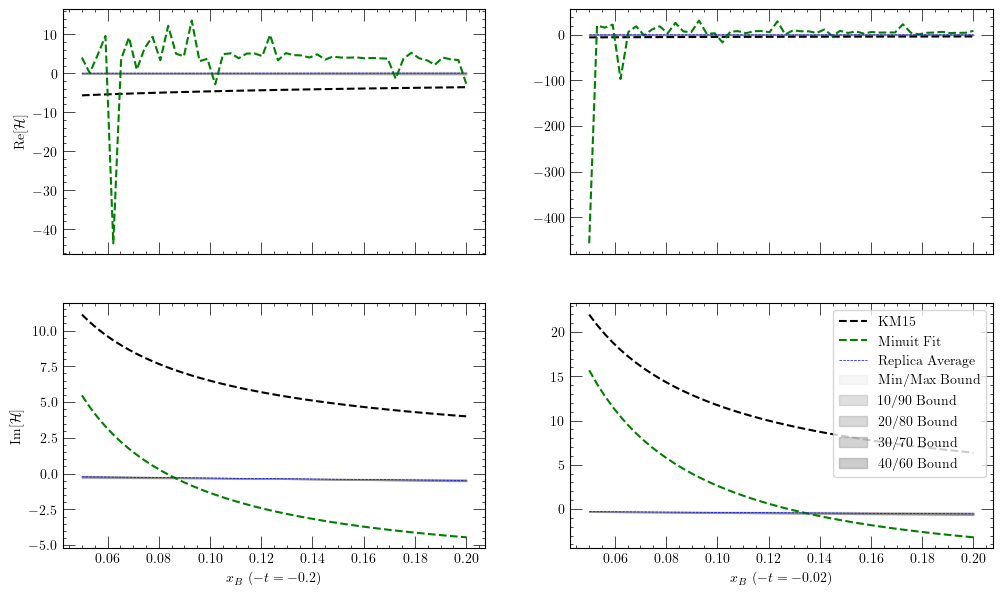

In [65]:
fig3, ax3 = plt.subplots(2, 2, sharex = True, figsize = (12, 7))

minuit_im_h_value_1 = minuit_cff_h_imag_cross_over(range_of_x_b, fixed_t_value_1, 
        _PARAM_N_VAL, cff_h_minuit.values['r_val'], cff_h_minuit.values['b_val'], cff_h_minuit.values['m_val_sq'], _PARAM_P_VAL,
        _PARAM_N_SEA, _PARAM_R_SEA, _PARAM_B_SEA, _PARAM_M_SEA_SQ, _PARAM_P_SEA, cff_h_minuit.values['c'])

minuit_im_h_value_2 = minuit_cff_h_imag_cross_over(range_of_x_b, fixed_t_value_2, 
        _PARAM_N_VAL, cff_h_minuit.values['r_val'], cff_h_minuit.values['b_val'], cff_h_minuit.values['m_val_sq'], _PARAM_P_VAL,
        _PARAM_N_SEA, _PARAM_R_SEA, _PARAM_B_SEA, _PARAM_M_SEA_SQ, _PARAM_P_SEA, cff_h_minuit.values['c'])

minuit_re_h_value_1 = minuit_cff_h_real_cross_over(
    range_of_x_b, fixed_t_value_1,
    _PARAM_N_VAL,  cff_h_minuit.values['r_val'], cff_h_minuit.values['b_val'], cff_h_minuit.values['m_val_sq'], _PARAM_P_VAL,
    _PARAM_N_SEA, _PARAM_R_SEA, _PARAM_B_SEA, _PARAM_M_SEA_SQ, _PARAM_P_SEA, cff_h_minuit.values['c'])

minuit_re_h_value_2 = minuit_cff_h_real_cross_over(
    range_of_x_b, fixed_t_value_2,
    _PARAM_N_VAL,  cff_h_minuit.values['r_val'], cff_h_minuit.values['b_val'], cff_h_minuit.values['m_val_sq'], _PARAM_P_VAL,
    _PARAM_N_SEA, _PARAM_R_SEA, _PARAM_B_SEA, _PARAM_M_SEA_SQ, _PARAM_P_SEA, cff_h_minuit.values['c'])

ax3[0][0].plot(
    range_of_x_b, km15_re_h_predictions_value_1, 
    color = "black", linestyle = "dashed", label = "KM15")

ax3[0][0].plot(
    range_of_x_b, minuit_re_h_value_1, 
    color = "green", linestyle = "dashed", label = "Minuit Fit")

ax3[0][1].plot(
    range_of_x_b, km15_re_h_predictions_value_2,
    color = "black", linestyle = "dashed", label = "KM15")

ax3[0][1].plot(
    range_of_x_b, minuit_re_h_value_2,
    color = "green", linestyle = "dashed", label = "Minuit Fit")

ax3[1][0].plot(
    range_of_x_b, km15_im_h_predictions_value_1,
    color = "black", linestyle = "dashed", label = "KM15")

ax3[1][0].plot(
    range_of_x_b, minuit_im_h_value_1,
    color = "green", linestyle = "dashed", label = "Minuit Fit")

ax3[1][1].plot(
    range_of_x_b, km15_im_h_predictions_value_2,
    color = "black", linestyle = "dashed", label = "KM15")

ax3[1][1].plot(
    range_of_x_b, minuit_im_h_value_2,
    color = "green", linestyle = "dashed", label = "Minuit Fit")

ax3[0][0].plot(
    range_of_x_b, cff_h_real_value_1_mean,
    label = r'Replica Average', color = "blue", linewidth = 0.5, linestyle = 'dashed')

ax3[0][0].fill_between(
    range_of_x_b, y1 = cff_h_real_value_1_max, y2 = cff_h_real_value_1_min,
    label = r'Min/Max Bound', color = "lightgray", alpha = 0.2)

ax3[0][0].fill_between(
    range_of_x_b, y1 = cff_h_real_value_1_percentile_90, y2 = cff_h_real_value_1_percentile_10,
    label = r'10/90 Bound', color = "gray", alpha = 0.25)

ax3[0][0].fill_between(
    range_of_x_b, y1 = cff_h_real_value_1_percentile_80, y2 = cff_h_real_value_1_percentile_20,
    label = r'20/80 Bound', color = "gray", alpha = 0.3)

ax3[0][0].fill_between(
    range_of_x_b, y1 = cff_h_real_value_1_percentile_70, y2 = cff_h_real_value_1_percentile_30,
    label = r'30/70 Bound', color = "gray", alpha = 0.35)

ax3[0][0].fill_between(
    range_of_x_b, y1 = cff_h_real_value_1_percentile_60, y2 = cff_h_real_value_1_percentile_40,
    label = r'40/60 Bound', color = "gray", alpha = 0.4)

ax3[0][1].plot(
    range_of_x_b, cff_h_real_value_2_mean,
    label = r'Replica Average', color = "blue", linewidth = 0.5, linestyle = 'dashed')

ax3[0][1].fill_between(
    range_of_x_b, y1 = cff_h_real_value_2_max, y2 = cff_h_real_value_2_min,
    label = r'Min/Max Bound', color = "lightgray", alpha = 0.2)

ax3[0][1].fill_between(
    range_of_x_b, y1 = cff_h_real_value_2_percentile_90, y2 = cff_h_real_value_2_percentile_10,
    label = r'10/90 Bound', color = "gray", alpha = 0.25)

ax3[0][1].fill_between(
    range_of_x_b, y1 = cff_h_real_value_2_percentile_80, y2 = cff_h_real_value_2_percentile_20,
    label = r'20/80 Bound', color = "gray", alpha = 0.3)

ax3[0][1].fill_between(
    range_of_x_b, y1 = cff_h_real_value_2_percentile_70, y2 = cff_h_real_value_2_percentile_30,
    label = r'30/70 Bound', color = "gray", alpha = 0.35)

ax3[0][1].fill_between(
    range_of_x_b, y1 = cff_h_real_value_2_percentile_60, y2 = cff_h_real_value_2_percentile_40,
    label = r'40/60 Bound', color = "gray", alpha = 0.4)

ax3[1][0].plot(
    range_of_x_b, cff_h_imag_value_1_mean,
    label = r'Replica Average', color = "blue", linewidth = 0.5, linestyle = 'dashed')

ax3[1][0].fill_between(
    range_of_x_b, y1 = cff_h_imag_value_1_max, y2 = cff_h_imag_value_1_min,
    label = r'Min/Max Bound', color = "lightgray", alpha = 0.2)

ax3[1][0].fill_between(
    range_of_x_b, y1 = cff_h_imag_value_1_percentile_90, y2 = cff_h_imag_value_1_percentile_10,
    label = r'10/90 Bound', color = "gray", alpha = 0.25)

ax3[1][0].fill_between(
    range_of_x_b, y1 = cff_h_imag_value_1_percentile_80, y2 = cff_h_imag_value_1_percentile_20,
    label = r'20/80 Bound', color = "gray", alpha = 0.3)

ax3[1][0].fill_between(
    range_of_x_b, y1 = cff_h_imag_value_1_percentile_70, y2 = cff_h_imag_value_1_percentile_30,
    label = r'30/70 Bound', color = "gray", alpha = 0.35)

ax3[1][0].fill_between(
    range_of_x_b, y1 = cff_h_imag_value_1_percentile_60, y2 = cff_h_imag_value_1_percentile_40,
    label = r'40/60 Bound', color = "gray", alpha = 0.4)

ax3[1][1].plot(
    range_of_x_b, cff_h_imag_value_2_mean,
    label = r'Replica Average', color = "blue", linewidth = 0.5, linestyle = 'dashed')

ax3[1][1].fill_between(
    range_of_x_b, y1 = cff_h_imag_value_2_max, y2 = cff_h_imag_value_2_min,
    label = r'Min/Max Bound', color = "lightgray", alpha = 0.2)

ax3[1][1].fill_between(
    range_of_x_b, y1 = cff_h_imag_value_2_percentile_90, y2 = cff_h_imag_value_2_percentile_10,
    label = r'10/90 Bound', color = "gray", alpha = 0.25)

ax3[1][1].fill_between(
    range_of_x_b, y1 = cff_h_imag_value_2_percentile_80, y2 = cff_h_imag_value_2_percentile_20,
    label = r'20/80 Bound', color = "gray", alpha = 0.3)

ax3[1][1].fill_between(
    range_of_x_b, y1 = cff_h_imag_value_2_percentile_70, y2 = cff_h_imag_value_2_percentile_30,
    label = r'30/70 Bound', color = "gray", alpha = 0.35)

ax3[1][1].fill_between(
    range_of_x_b, y1 = cff_h_imag_value_2_percentile_60, y2 = cff_h_imag_value_2_percentile_40,
    label = r'40/60 Bound', color = "gra    y", alpha = 0.4)

ax3[0][0].set_ylabel(r"Re$[\mathcal{H}]$")
ax3[1][0].set_ylabel(r"Im$[\mathcal{H}]$")
ax3[1][0].set_xlabel(rf'$x_{{B}}$ ($-t = {{{fixed_t_value_1}}}$)')
ax3[1][1].set_xlabel(rf'$x_{{B}}$ ($-t = {{{fixed_t_value_2}}}$)')

plt.legend()

fig3.savefig(f"./version_{VERSION_NUMBER}/plots/dnn_cff_h_vs_kinematics_v{MAJOR_MINOR_NUMBER}.png")
fig3.savefig(f"./version_{VERSION_NUMBER}/plots/dnn_cff_h_vs_kinematics_v{MAJOR_MINOR_NUMBER}.eps")

plt.show()
plt.close()